# Flood-wave travel time from stream gages — Cypress Creek, Houston TX

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/jdf9/cypress-gage-travel-time/blob/main/cypress_gage_hydrographs_travel_time.ipynb)

**What this notebook does**

1. Finds every USGS stream gage on a river (Cypress Creek) from the USGS Water Data API.
2. Works out which gages have 15-minute **flow** and **stage** during two floods — **Tax Day 2016** and **Hurricane Harvey 2017**.
3. Puts the gages in upstream → downstream order and measures the **channel distance** between them from the national hydrography network (NHDPlus via NLDI)no shapefiles.
4. Downloads and plots the flow and stage hydrographs at every gage.
5. Estimates how long the flood wave took to travel between gages (peak-to-peak timing **and** cross-correlation), converts that into a **wave celerity**, and compares the two storms.
6. Re-runs the whole pipeline on the **Guadalupe River** (Texas Hill Country) with a one-line change, so you can see that nothing here is Cypress-specific.

**Skills you will leave with:** querying USGS monitoring locations, time-series metadata, instantaneous values and the NLDI network with `dataretrieval`; handling time zones correctly; tidy → wide reshaping in pandas; peak detection and lagged cross-correlation in numpy.

**Runtime:** about 2 minutes in Colab (all data are pulled live; nothing is stored in the repo).
**Prerequisites:** basic Python and pandas. No hydrology background is assumed — the physical ideas are explained where they appear.

> **To use this on another river** you change three things in the *Configuration* cell: the hydrologic-unit code + name pattern that identify the river, the event windows, and (optionally) the exclusion list for tributaries. Everything else is generic. Section 10 does  that for the Guadalupe River.

## 0 · Setup

Colab already has numpy, pandas, matplotlib, scipy and geopandas. The only extra package is
[`dataretrieval`](https://github.com/DOI-USGS/dataretrieval-python), the USGS's own Python client.
We use its `waterdata` module (the **new** USGS Water Data APIs at `api.waterdata.usgs.gov`) and its
`nldi` module (the Network-Linked Data Index). The legacy `nwis` module still works but is being retired.

You will see a one-time line *"No API key detected"* — ignore it. The notebook makes a few dozen requests, well
inside the anonymous rate limit. (If you script hundreds of sites, register a free key at
<https://api.waterdata.usgs.gov/signup/> and set the `API_USGS_PAT` environment variable.)

In [1]:
import subprocess, sys, warnings
try:
    import dataretrieval
    assert tuple(int(x) for x in dataretrieval.__version__.split(".")[:2]) >= (1, 3)
except Exception:
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "dataretrieval>=1.3"], check=True)
    import dataretrieval

import re
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy.signal import find_peaks
from dataretrieval import waterdata, nldi

warnings.filterwarnings("ignore")
pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 40)
print("dataretrieval", dataretrieval.__version__, "| pandas", pd.__version__, "| geopandas", gpd.__version__)

dataretrieval 1.3.0 | pandas 2.2.3 | geopandas 1.1.4


In [2]:
# ── Plot style: one fixed categorical palette (colour follows the gage, never its rank), recessive chrome.
PALETTE = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
INK, INK2, MUTED, GRID, AXIS, SURFACE = "#0b0b0b", "#52514e", "#898781", "#e1e0d9", "#c3c2b7", "#fcfcfb"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": SURFACE, "axes.facecolor": SURFACE, "savefig.facecolor": SURFACE,
    "axes.edgecolor": AXIS, "axes.labelcolor": INK2, "axes.titlecolor": INK, "axes.titleweight": "semibold",
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED, "xtick.labelcolor": INK2, "ytick.labelcolor": INK2,
    "lines.linewidth": 1.6, "legend.frameon": False, "font.size": 9.5, "axes.titlesize": 10.5,
})
KM_PER_MI = 1.609344

## 1 · Configuration — the only cell you need to edit for a new river

A river is identified by a **hydrologic unit code (HUC) prefix** and a **name pattern**.
USGS station names follow a house style (`Cypress Ck at Grant Rd nr Cypress, TX`, `Guadalupe Rv at Comfort, TX`),
so a SQL `LIKE` pattern on the name plus the HUC-8 or HUC-10 of the basin is usually enough to pull the whole river.
Look up HUCs at <https://water.usgs.gov/wsc/map_index.html> or on any gage's USGS page.

Event windows are **local calendar dates** (inclusive). Make them generous — a couple of days before the rain and
enough after it for the downstream-most gage to recede — because we will hunt for the peak inside the window.

`max_lag_hours` is the longest travel time you are prepared to believe for one reach — the downstream response is
searched for only that far after the upstream peak. `xcorr_window_hours` is the half-width of the slice of upstream
hydrograph (centred on its peak) that the cross-correlation tries to find again downstream. Set both from the
size of the river: a day or two for a sluggish coastal-plain stream, a few hours for a Hill Country flash flood.

In [3]:
CONFIGS = {
    "cypress": dict(
        title="Cypress Creek, Harris County, TX",
        huc_prefix="1204010201",        # HUC-10 of Cypress Creek (inside Spring HUC-8 12040102)
        name_like="%Cypress Ck%",       # SQL LIKE pattern matched against the USGS station name
        exclude=["Little Cypress"],     # station-name fragments to drop (tributaries, duplicates)
        tz="America/Chicago",           # local time zone for plots and tables
        events={                        # label: (start, end) as local calendar dates, inclusive
            "Tax Day 2016": ("2016-04-16", "2016-04-26"),
            "Harvey 2017":  ("2017-08-25", "2017-09-06"),
        },
        max_lag_hours=48,               # longest believable travel time for one reach (search window after the upstream peak)
        xcorr_window_hours=12,          # half-width of the upstream pulse used as the cross-correlation template
        override_order=None,            # list of site ids upstream→downstream, if you don't trust the automatic order
        override_distance_km=None,      # {(up_site, dn_site): km, ...} to use surveyed distances instead of NLDI
    ),
    "guadalupe_upper": dict(
        title="Guadalupe River above Canyon Lake, TX",
        huc_prefix="12100201",          # HUC-8 Upper Guadalupe
        name_like="%Guadalupe Rv%",
        exclude=["N Fk", "S Fk"],       # the forks above Hunt — we start the main stem at Hunt
        tz="America/Chicago",
        events={
            "October 2018": ("2018-10-14", "2018-10-20"),
            "July 2025":    ("2025-07-03", "2025-07-09"),
        },
        max_lag_hours=24,
        xcorr_window_hours=6,
        override_order=None,
        override_distance_km=None,
    ),
}

RIVER = "cypress"          # ← change to "guadalupe_upper" (or your own entry) and Run all
CFG = CONFIGS[RIVER]
EVENT_COLORS = dict(zip(CFG["events"], PALETTE))
print(CFG["title"]); print({k: v for k, v in CFG["events"].items()})

Cypress Creek, Harris County, TX
{'Tax Day 2016': ('2016-04-16', '2016-04-26'), 'Harvey 2017': ('2017-08-25', '2017-09-06')}


## 2 · Find the gages

`waterdata.get_monitoring_locations` accepts a CQL filter, which lets us combine a HUC prefix, the site type
(`ST` = stream) and a name pattern in one request. The result is a GeoDataFrame (it carries a point geometry),
so we keep latitude/longitude for the map later. `drainage_area` (mi²) is the single most useful column: on a
main stem it increases monotonically downstream, which is how we will order the gages.

In [4]:
def find_gages(huc_prefix, name_like, exclude=()):
    '''Stream gages whose HUC starts with `huc_prefix` and whose name matches the SQL LIKE pattern.'''
    flt = (f"hydrologic_unit_code LIKE '{huc_prefix}%' AND site_type_code='ST' "
           f"AND monitoring_location_name LIKE '{name_like}'")
    gdf, _ = waterdata.get_monitoring_locations(filter=flt, skip_geometry=False)
    if exclude:
        pat = "|".join(re.escape(e) for e in exclude)
        gdf = gdf[~gdf.monitoring_location_name.str.contains(pat, regex=True)]
    g = gdf[["monitoring_location_id", "monitoring_location_name", "drainage_area", "hydrologic_unit_code", "geometry"]]
    g = g.rename(columns={"monitoring_location_id": "site", "monitoring_location_name": "name", "drainage_area": "da_mi2"})
    g = g.assign(lon=g.geometry.x, lat=g.geometry.y)
    return g.sort_values("da_mi2").reset_index(drop=True)

def short_name(name, keep_prep=False):
    '''Cypress Ck at Katy-Hockley Rd nr Hockley, TX -> Katy-Hockley Rd;  Guadalupe Rv at Comfort, TX -> Comfort.'''
    body = re.sub(r",\s*[A-Z]{2}$", "", name)                            # drop the ', TX'
    m = re.match(r"^(.*?)\s(at|nr|near|abv|bl|blw)\s(.*)$", body)         # river | preposition | place
    if not m: return body
    prep, place = m.group(2), re.sub(r"\s(?:nr|near)\s.*$", "", m.group(3))   # drop a trailing ' nr Town'
    return f"{prep} {place}" if (keep_prep or prep in ("abv", "bl", "blw")) else place

def add_labels(g):
    '''Short labels; where two stations share a place name ("at Comfort" / "nr Comfort") keep the preposition.'''
    g = g.assign(label=g["name"].map(short_name))
    dup = g.label.duplicated(keep=False)
    g.loc[dup, "label"] = g.loc[dup, "name"].map(lambda n: short_name(n, keep_prep=True))
    return g

gages = add_labels(find_gages(CFG["huc_prefix"], CFG["name_like"], CFG["exclude"]))
gages[["site", "name", "label", "da_mi2", "hydrologic_unit_code", "lon", "lat"]]

,site,name,label,da_mi2,hydrologic_unit_code,lon,lat
0,USGS-08068700,"Cypress Ck at Sharp Rd nr Hockley, TX",Sharp Rd,80.7,120401020103,-95.840229,29.921058
1,USGS-08068720,"Cypress Ck at Katy-Hockley Rd nr Hockley, TX",Katy-Hockley Rd,110.0,120401020103,-95.808283,29.950224
2,USGS-08068740,"Cypress Ck at House-Hahl Rd nr Cypress, TX",House-Hahl Rd,131.0,120401020104,-95.717725,29.959112
3,USGS-08068750,"Cypress Ck nr Cypress, TX",Cypress,138.0,120401020104,-95.678279,29.956612
4,USGS-08068800,"Cypress Ck at Grant Rd nr Cypress, TX",Grant Rd,214.0,120401020106,-95.598554,29.973556
5,USGS-08068900,Cypress Ck at Stuebner-Airline Rd nr Westfield...,Stuebner-Airline Rd,248.0,120401020106,-95.511885,30.006610
6,USGS-08069000,"Cypress Ck nr Westfield, TX",Westfield,285.0,120401020107,-95.428827,30.035775
7,USGS-08069200,"Cypress Ck nr Humble, TX",Humble,319.0,120401020107,-95.329935,30.030497
8,USGS-300119095283800,"Cypress Ck at Kuykendahl Rd nr Houston, TX",Kuykendahl Rd,NaN,120401020107,-95.477222,30.021944


## 3 · Which gages actually have 15-minute data during our events?

A site listing is not a data listing. Several of the sites above are discontinued, stage-only, or were installed
after our storms. `get_time_series_metadata` tells us, per site and parameter, when continuous data begin and end.
Parameter codes: **00060** = discharge (ft³/s), **00065** = gage height (ft). Statistic **00011** = instantaneous
(the 15-minute record), as opposed to daily means/maxima.

We keep a gage if it has flow *or* stage covering at least one event. Stage-only gages are still useful for
**timing** (when did the water rise?) even though they cannot give a discharge.

In [5]:
def iv_availability(sites, pcodes=("00060", "00065")):
    '''Wide table: for each site, first/last date of instantaneous flow and stage.'''
    ts, _ = waterdata.get_time_series_metadata(monitoring_location_id=list(sites),
                                               parameter_code=list(pcodes), statistic_id="00011")
    ts = ts.dropna(subset=["begin"])
    av = (ts.groupby(["monitoring_location_id", "parameter_code"])
            .agg(begin=("begin", "min"), end=("end", "max")).reset_index())
    av["begin"], av["end"] = av["begin"].dt.date, av["end"].dt.date
    wide = av.pivot(index="monitoring_location_id", columns="parameter_code", values=["begin", "end"])
    wide.columns = [f"{'flow' if p == '00060' else 'stage'}_{k}" for k, p in wide.columns]
    return wide.reset_index().rename(columns={"monitoring_location_id": "site"})

def covers(begin, end, start, stop):
    '''True if a record spanning [begin, end] overlaps the event [start, stop].'''
    if pd.isna(begin): return False
    return (pd.Timestamp(begin) <= pd.Timestamp(stop)) and (pd.Timestamp(end) >= pd.Timestamp(start))

avail = iv_availability(gages["site"])
gages = gages.merge(avail, on="site", how="left")
for col in ["flow_begin", "flow_end", "stage_begin", "stage_end"]:
    if col not in gages: gages[col] = pd.NaT

for ev, (start, stop) in CFG["events"].items():
    gages[f"flow:{ev}"]  = [covers(b, e, start, stop) for b, e in zip(gages.flow_begin,  gages.flow_end)]
    gages[f"stage:{ev}"] = [covers(b, e, start, stop) for b, e in zip(gages.stage_begin, gages.stage_end)]

ev_cols = [c for c in gages if ":" in c]
gages["usable"] = gages[ev_cols].any(axis=1)
gages[["site", "label", "da_mi2", "flow_begin", "stage_begin"] + ev_cols + ["usable"]]

,site,label,da_mi2,flow_begin,stage_begin,flow:Tax Day 2016,stage:Tax Day 2016,flow:Harvey 2017,stage:Harvey 2017,usable
0,USGS-08068700,Sharp Rd,80.7,NaN,2007-10-01,False,True,False,True,True
1,USGS-08068720,Katy-Hockley Rd,110.0,1989-05-16,2007-10-02,True,True,True,True,True
2,USGS-08068740,House-Hahl Rd,131.0,2007-10-01,2007-10-01,True,True,True,True,True
3,USGS-08068750,Cypress,138.0,NaN,NaN,False,False,False,False,False
4,USGS-08068800,Grant Rd,214.0,2007-10-01,2007-10-01,True,True,True,True,True
5,USGS-08068900,Stuebner-Airline Rd,248.0,1989-05-16,2007-10-01,True,True,True,True,True
6,USGS-08069000,Westfield,285.0,1989-05-16,2007-10-01,True,True,True,True,True
7,USGS-08069200,Humble,319.0,NaN,NaN,False,False,False,False,False
8,USGS-300119095283800,Kuykendahl Rd,NaN,NaN,NaN,False,False,False,False,False


## 4 · Put the gages in order and measure the channel between them

Two things a travel-time analysis needs that a site list does not give: **which gages sit on the same channel**
(a tributary gage is upstream of nothing on the main stem) and the **distance along the channel** between
consecutive gages.

Both come from the USGS **Network-Linked Data Index (NLDI)**, a web service over the NHDPlus river network:

* `nldi.get_features(..., navigation_mode="UM", data_source="nwissite")` starting from the most downstream gage
  returns every USGS gage on the *upstream main* path — that is our main-stem membership test.
* `nldi.get_flowlines(..., navigation_mode="DM")` returns the NHDPlus flowlines *downstream main* of a gage.
  The flowlines downstream of gage *A* that are **not** also downstream of gage *B* are exactly the reaches between
  *A* and *B*. Each gage sits part-way along its own flowline (the `measure`, 0 % at the downstream end,
  100 % at the upstream end), so we trim the two end reaches accordingly.

The medium-resolution NHDPlus flowlines are smoother than a surveyed centerline, so expect distances within
roughly ±10 % of engineering river miles. If you have better numbers, put them in `override_distance_km`.

In [6]:
def main_stem_members(downstream_site, candidates, max_km=600):
    '''Subset of `candidates` that lie on the upstream-main path from `downstream_site` (plus itself).'''
    up = nldi.get_features(feature_source="nwissite", feature_id=downstream_site,
                           navigation_mode="UM", data_source="nwissite", distance=max_km)
    on_stem = set(up["identifier"]) | {downstream_site}
    return [s for s in candidates if s in on_stem]

def gage_position(site):
    '''(comid, measure %) of the NHDPlus flowline a gage sits on.'''
    f = nldi.get_features(feature_source="nwissite", feature_id=site)
    return int(f["comid"].iloc[0]), float(f["measure"].iloc[0])

def downstream_flowlines(site, max_km=600):
    '''Flowlines downstream-main of `site`, with lengths in km (CONUS Albers, EPSG:5070).'''
    fl = nldi.get_flowlines(feature_source="nwissite", feature_id=site, navigation_mode="DM", distance=max_km)
    fl["len_km"] = fl.to_crs(5070).length.values / 1000.0
    return fl

def reach_distance_km(up_site, dn_site, pos, dm):
    '''Channel distance between two main-stem gages from their downstream-main flowline sets.'''
    (c_up, m_up), (c_dn, m_dn) = pos[up_site], pos[dn_site]
    between = dm[up_site][~dm[up_site].nhdplus_comid.isin(dm[dn_site].nhdplus_comid)]
    L_up = float(dm[up_site].loc[dm[up_site].nhdplus_comid == c_up, "len_km"].iloc[0])
    L_dn = float(dm[dn_site].loc[dm[dn_site].nhdplus_comid == c_dn, "len_km"].iloc[0])
    full = between["len_km"].sum()
    return full - L_up + L_up * m_up / 100.0 + L_dn * (1 - m_dn / 100.0), between

usable = gages[gages.usable].sort_values("da_mi2")
outlet = usable.iloc[-1]["site"]                                    # largest drainage area = most downstream
stem_sites = main_stem_members(outlet, usable["site"].tolist())
if CFG["override_order"]:
    stem_sites = [s for s in CFG["override_order"] if s in set(usable["site"])]
stem = usable[usable.site.isin(stem_sites)].set_index("site").loc[stem_sites].reset_index()
stem["color"] = PALETTE[:len(stem)]
if len(stem) > len(PALETTE):
    raise ValueError("More than 8 main-stem gages — split the river into two reaches (the palette is fixed at 8).")

pos = {s: gage_position(s) for s in stem.site}
dm  = {s: downstream_flowlines(s) for s in stem.site}

reaches = []
for up_site, dn_site in zip(stem.site[:-1], stem.site[1:]):
    d_km, between = reach_distance_km(up_site, dn_site, pos, dm)
    if CFG["override_distance_km"] and (up_site, dn_site) in CFG["override_distance_km"]:
        d_km = CFG["override_distance_km"][(up_site, dn_site)]
    reaches.append(dict(up=up_site, dn=dn_site, up_label=stem.set_index("site").label[up_site],
                        dn_label=stem.set_index("site").label[dn_site], dist_km=d_km, dist_mi=d_km / KM_PER_MI,
                        n_flowlines=len(between)))
reaches = pd.DataFrame(reaches)
stem["dist_from_top_mi"] = np.r_[0.0, reaches["dist_mi"].cumsum().to_numpy()]

print("Main-stem gages, upstream → downstream:")
display(stem[["site", "label", "da_mi2", "dist_from_top_mi"]].round(2))
print("\nReaches between consecutive gages:")
display(reaches[["up_label", "dn_label", "dist_km", "dist_mi", "n_flowlines"]].round(2))

Main-stem gages, upstream → downstream:


,site,label,da_mi2,dist_from_top_mi
0,USGS-08068700,Sharp Rd,80.7,0.00
1,USGS-08068720,Katy-Hockley Rd,110.0,3.29
2,USGS-08068740,House-Hahl Rd,131.0,9.22
3,USGS-08068800,Grant Rd,214.0,19.89
4,USGS-08068900,Stuebner-Airline Rd,248.0,28.09
5,USGS-08069000,Westfield,285.0,35.43



Reaches between consecutive gages:


,up_label,dn_label,dist_km,dist_mi,n_flowlines
0,Sharp Rd,Katy-Hockley Rd,5.30,3.29,2
1,Katy-Hockley Rd,House-Hahl Rd,9.54,5.93,4
2,House-Hahl Rd,Grant Rd,17.17,10.67,7
3,Grant Rd,Stuebner-Airline Rd,13.20,8.20,6
4,Stuebner-Airline Rd,Westfield,11.81,7.34,2


### Map

The main stem is drawn from the same NLDI flowlines we just measured. Main-stem gages carry their colour for the
rest of the notebook; grey hollow markers are gages we found but are not using (tributaries, discontinued, or no
data in our windows — see the tables in §2 and §3 for which is which).

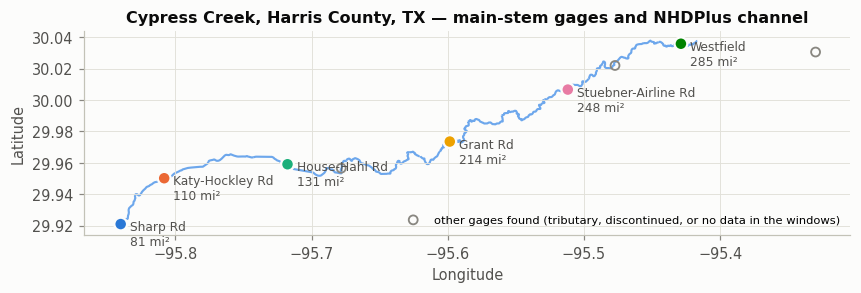

In [7]:
def plot_map(stem, gages, dm, pos, title):
    top, bottom = stem.site.iloc[0], stem.site.iloc[-1]
    stem_lines = dm[top][~dm[top].nhdplus_comid.isin(dm[bottom].nhdplus_comid) | (dm[top].nhdplus_comid == pos[bottom][0])]
    fig, ax = plt.subplots(figsize=(8, 5.2))
    stem_lines.plot(ax=ax, color="#6da7ec", linewidth=1.4, zorder=1)
    others = gages[~gages.site.isin(stem.site)]
    ax.scatter(others.lon, others.lat, s=34, facecolor="none", edgecolor=MUTED, linewidth=1.2, zorder=2,
               label="other gages found (tributary, discontinued, or no data in the windows)")
    ax.scatter(stem.lon, stem.lat, s=70, c=stem.color, edgecolor=SURFACE, linewidth=1.5, zorder=3)
    ax.legend(loc="lower right", fontsize=7.5)
    for _, r in stem.iterrows():
        ax.annotate(f"{r.label}\n{r.da_mi2:,.0f} mi²", (r.lon, r.lat), xytext=(6, -14), textcoords="offset points",
                    fontsize=8, color=INK2)
    ax.set_xlabel("Longitude"); ax.set_ylabel("Latitude"); ax.set_title(f"{title} — main-stem gages and NHDPlus channel")
    ax.set_aspect(1 / np.cos(np.deg2rad(stem.lat.mean())))
    plt.tight_layout(); plt.show()

plot_map(stem, gages, dm, pos, CFG["title"])

## 5 · Download the hydrographs

`waterdata.get_continuous` returns a **tidy** (long) table: one row per site × parameter × timestamp. Timestamps
are **UTC**. Two habits worth keeping for life:

* **Do the math in UTC, display in local time.** We convert the event's local calendar dates to a UTC interval
  for the request, keep the index in UTC while resampling, and convert to local only at the end. Mixing a
  "naive" local clock with a UTC clock is the single most common way to get a travel time wrong by 5–6 hours.
* **Regularise the time step before comparing gages.** Some gages report every 5 min, some every 15, and all
  have gaps. We resample everything to a common 15-minute grid and interpolate gaps of up to one hour only.

In [8]:
def fetch_iv(sites, start, stop, tz, pcodes=("00060", "00065")):
    '''Tidy instantaneous values for `sites` over local dates [start, stop] (inclusive).'''
    t0 = pd.Timestamp(start, tz=tz).tz_convert("UTC")
    t1 = (pd.Timestamp(stop, tz=tz) + pd.Timedelta(days=1)).tz_convert("UTC")
    interval = f"{t0:%Y-%m-%dT%H:%M:%SZ}/{t1:%Y-%m-%dT%H:%M:%SZ}"
    frames = []
    for s in sites:
        df, _ = waterdata.get_continuous(monitoring_location_id=s, parameter_code=list(pcodes), time=interval)
        if len(df):
            frames.append(df[["monitoring_location_id", "parameter_code", "time", "value", "approval_status"]])
    iv = pd.concat(frames, ignore_index=True).rename(columns={"monitoring_location_id": "site"})
    return iv

def to_wide(iv, pcode, tz, freq="15min", gap_limit=4):
    '''Long → wide (index = local time, columns = site) on a regular grid; gaps ≤ gap_limit steps interpolated.'''
    sub = iv[iv.parameter_code == pcode]
    if sub.empty: return pd.DataFrame()
    w = sub.pivot_table(index="time", columns="site", values="value")
    w = w.resample(freq).mean().interpolate(limit=gap_limit, limit_area="inside")
    w.index = w.index.tz_convert(tz)
    return w

DATA = {}
for ev, (start, stop) in CFG["events"].items():
    iv = fetch_iv(stem.site, start, stop, CFG["tz"])
    Q, H = to_wide(iv, "00060", CFG["tz"]), to_wide(iv, "00065", CFG["tz"])
    DATA[ev] = dict(raw=iv, Q=Q, H=H, window=(start, stop))
    qa = (iv.groupby(["site", "parameter_code"])
            .agg(n=("value", "size"), provisional=("approval_status", lambda s: (s != "Approved").mean()))
            .unstack("parameter_code"))
    print(f"{ev}: {len(iv):,} rows | flow at {Q.shape[1]} gages, stage at {H.shape[1]} gages")
    display(qa.round(2))

Tax Day 2016: 11,107 rows | flow at 5 gages, stage at 6 gages


n         provisional      
parameter_code   00060   00065       00060 00065
site                                            
USGS-08068700      NaN  1049.0         NaN   0.0
USGS-08068720    865.0  1057.0         0.0   0.0
USGS-08068740   1007.0  1007.0         0.0   0.0
USGS-08068800   1049.0  1049.0         0.0   0.0
USGS-08068900    860.0  1050.0         0.0   0.0
USGS-08069000   1057.0  1057.0         0.0   0.0

Harvey 2017: 12,594 rows | flow at 5 gages, stage at 6 gages


n         provisional      
parameter_code   00060   00065       00060 00065
site                                            
USGS-08068700      NaN  1249.0         NaN   0.0
USGS-08068720   1249.0  1249.0         0.0   0.0
USGS-08068740   1249.0  1249.0         0.0   0.0
USGS-08068800    852.0   796.0         0.0   0.0
USGS-08068900   1070.0  1133.0         0.0   0.0
USGS-08069000   1249.0  1249.0         0.0   0.0

### Which record do we time from?

Discharge is the natural choice, but a discharge record is *computed* from stage through a rating curve, and
in a big flood it is often **censored** — the USGS withholds values above the rating or while the gage was
drowned, and fills them in months later. A gap across the crest hands you the wrong peak. So for every gage and
event we check the record's **coverage** and **longest internal gap** and fall back to stage when discharge fails
the test. Stage is measured directly and rarely has that problem (it has others: the datum differs at every gage,
and a stage that flat-tops at the level of an overflow tells you about the overflow, not the wave).

In [9]:
def series_quality(s, window, tz, step_min=15):
    '''(coverage fraction of the event window, longest internal gap in hours) for a gridded series.'''
    start, stop = window
    n_expected = (pd.Timestamp(stop, tz=tz) + pd.Timedelta(days=1) - pd.Timestamp(start, tz=tz)) / pd.Timedelta(minutes=step_min)
    valid = s.notna()
    if not valid.any(): return 0.0, np.inf
    inner = valid[s.first_valid_index(): s.last_valid_index()]
    gaps = (~inner).astype(int).groupby(inner.cumsum()).sum()         # NaN run-lengths between valid samples
    return float(valid.sum() / n_expected), float(gaps.max() * step_min / 60)

def timing_series(site, Q, H, window, tz, min_coverage=0.8, max_gap_h=6):
    '''Series used for timing at one gage: discharge if its record is complete enough, otherwise stage.
    Complete enough = covers ≥ 80 % of the window with no internal gap longer than 6 h. Returns (series, basis, note).'''
    notes = []
    for W, basis in [(Q, "flow"), (H, "stage")]:
        if site in W and W[site].notna().sum() > 10:
            cov, gap = series_quality(W[site], window, tz)
            if cov >= min_coverage and gap <= max_gap_h:
                return W[site], basis, "; ".join(notes)
            notes.append(f"{basis} rejected: {cov:.0%} coverage, longest gap {gap:.1f} h")
        else:
            notes.append(f"no {basis}")
    return None, None, "; ".join(notes)

def timing_basis_table(ev, Q, H, stem, window, tz):
    rows = []
    for _, r in stem.iterrows():
        _, basis, note = timing_series(r.site, Q, H, window, tz)
        rows.append(dict(event=ev, gage=r.label, timing_basis=basis or "— unusable", note=note))
    return pd.DataFrame(rows)

BASIS = pd.concat([timing_basis_table(ev, DATA[ev]["Q"], DATA[ev]["H"], stem, DATA[ev]["window"], CFG["tz"])
                   for ev in CFG["events"]], ignore_index=True)
display(BASIS)

,event,gage,timing_basis,note
0,Tax Day 2016,Sharp Rd,stage,no flow
1,Tax Day 2016,Katy-Hockley Rd,stage,"flow rejected: 82% coverage, longest gap 47.0 h"
2,Tax Day 2016,House-Hahl Rd,flow,
3,Tax Day 2016,Grant Rd,flow,
4,Tax Day 2016,Stuebner-Airline Rd,flow,
5,Tax Day 2016,Westfield,flow,
6,Harvey 2017,Sharp Rd,stage,no flow
7,Harvey 2017,Katy-Hockley Rd,flow,
8,Harvey 2017,House-Hahl Rd,flow,
9,Harvey 2017,Grant Rd,flow,


## 6 · Stacked hydrographs — the flood wave marching downstream

Rows are gages in upstream → downstream order; left column is discharge, right column is stage.
Shared time axes make the lag visible directly: the peak steps to the right as you read down the page.
Stage panels have different vertical datums at every gage, so compare their **timing**, not their values.
The dot marks each series' maximum inside the window.

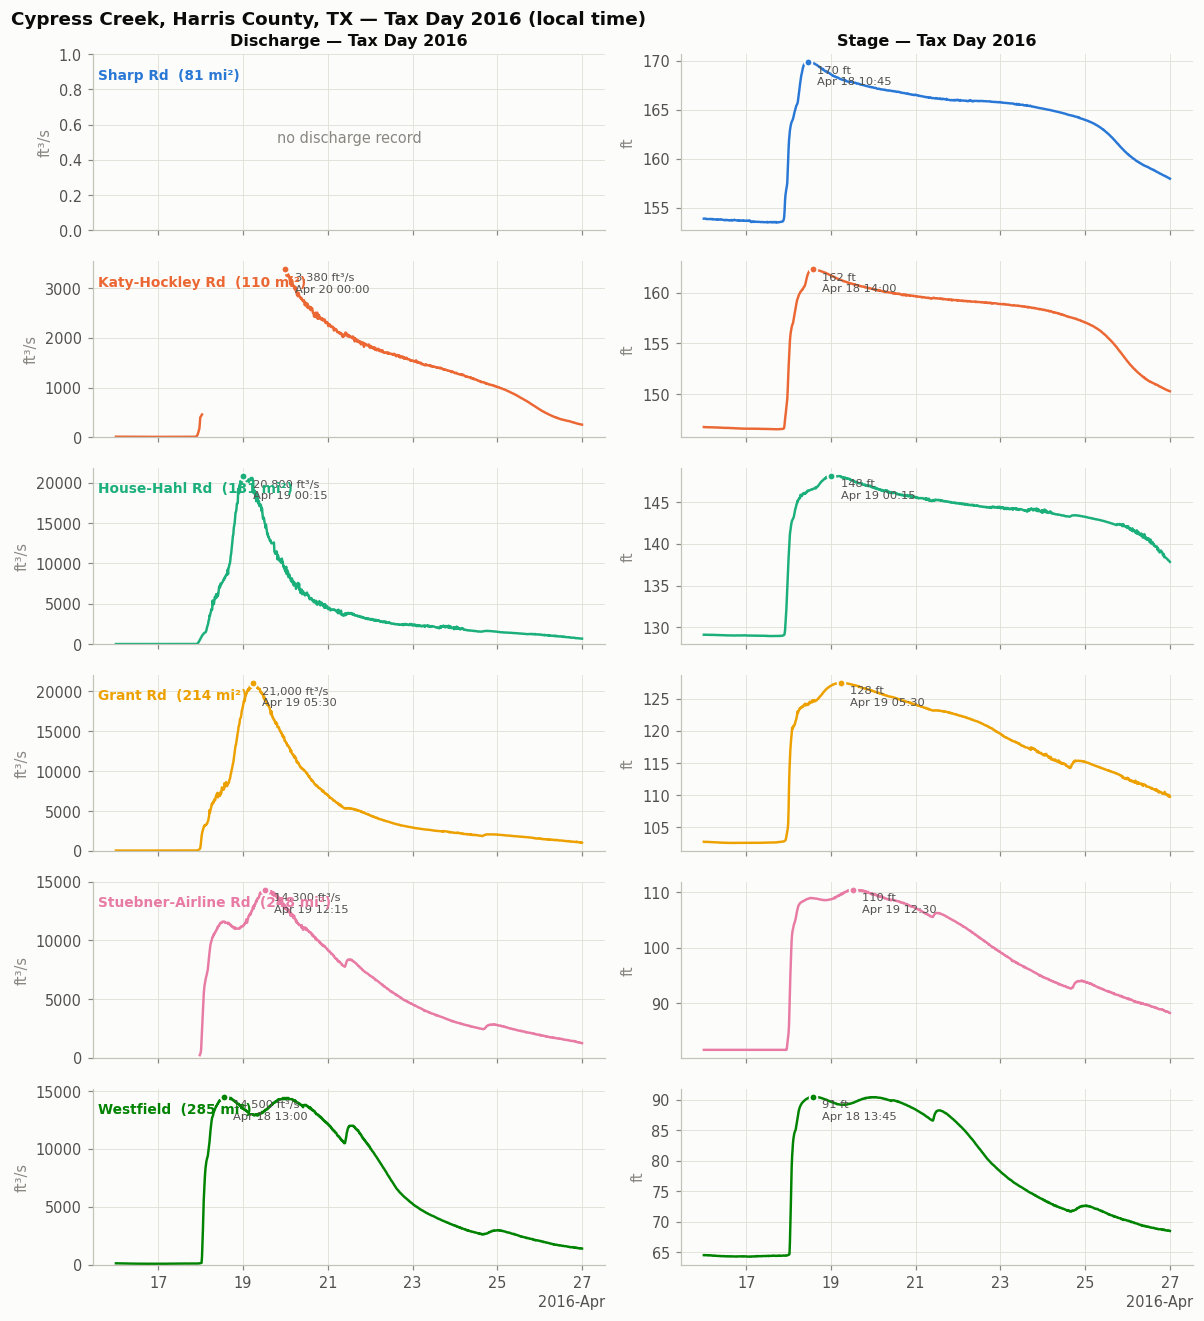

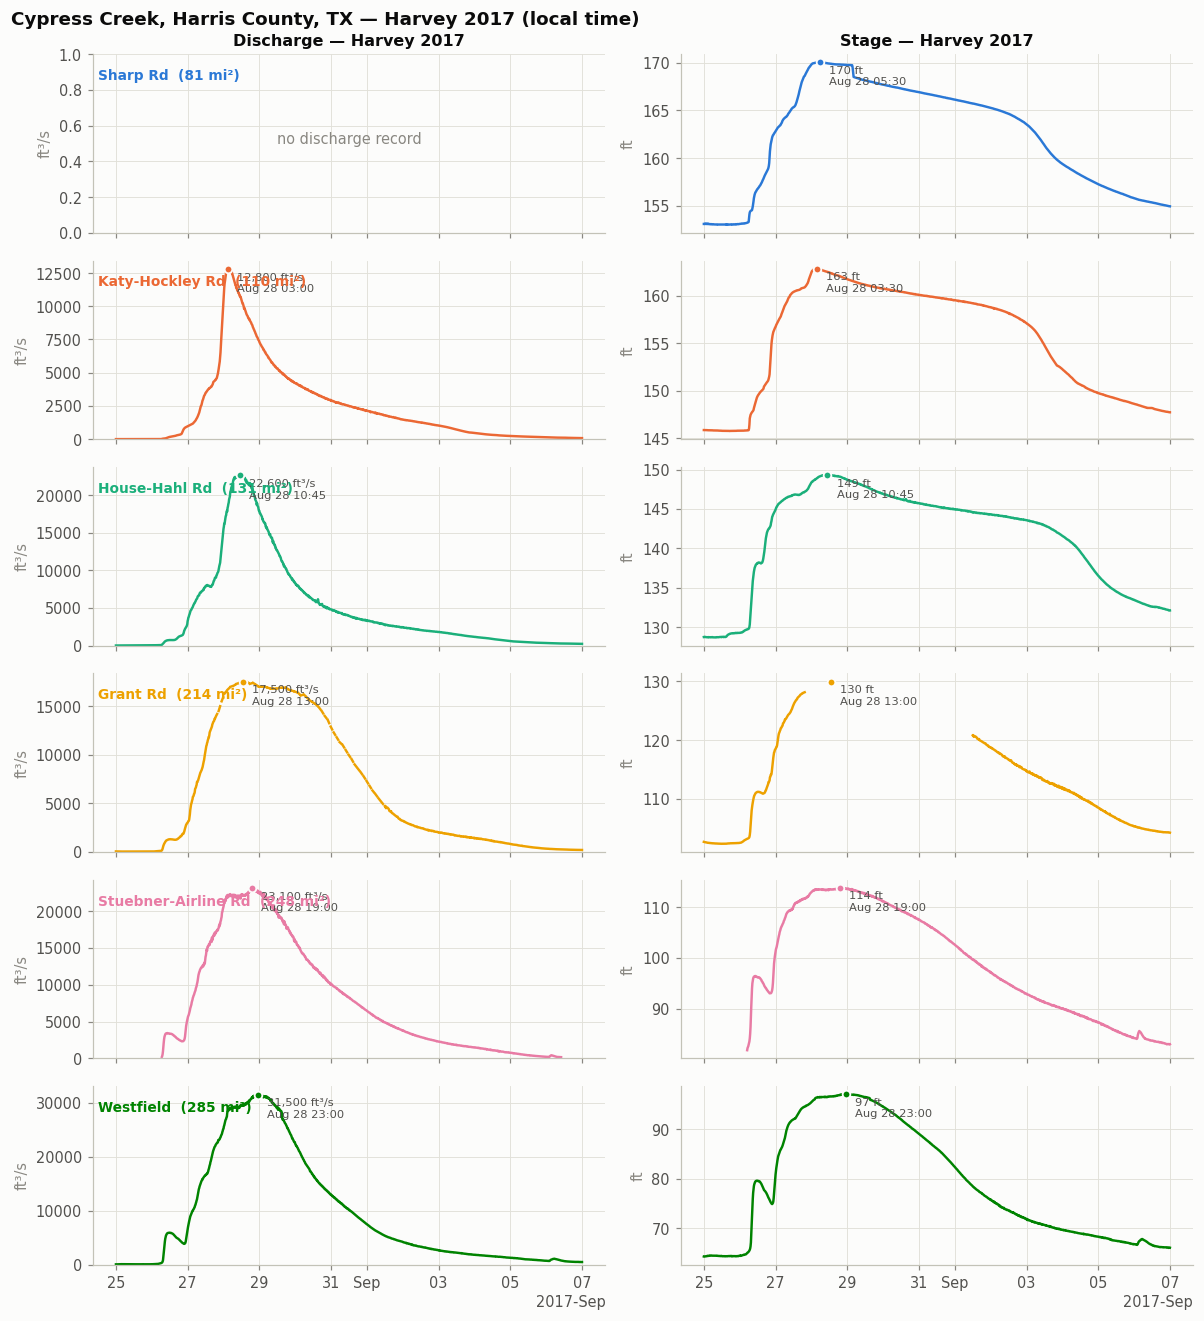

In [10]:
def naive(idx):        # tz-aware local → naive local, for matplotlib
    return idx.tz_localize(None)

def plot_stacked(ev, Q, H, stem):
    n = len(stem)
    fig, axes = plt.subplots(n, 2, figsize=(11, 1.9 * n + 0.8), sharex=True, squeeze=False)
    for i, r in stem.reset_index(drop=True).iterrows():
        for j, (W, unit, kind) in enumerate([(Q, "ft³/s", "Discharge"), (H, "ft", "Stage")]):
            ax = axes[i, j]
            if r.site in W and W[r.site].notna().any():
                s = W[r.site]
                ax.plot(naive(s.index), s.values, color=r.color)
                t, v = s.idxmax(), s.max()
                ax.plot(t.tz_localize(None), v, "o", ms=5, color=r.color, mec=SURFACE, mew=1.2)
                ax.annotate(f"{v:,.0f} {unit}\n{t:%b %d %H:%M}", (t.tz_localize(None), v),
                            xytext=(6, -2), textcoords="offset points", fontsize=7.5, color=INK2, va="top")
                ax.set_ylim(bottom=min(0, s.min()) if kind == "Discharge" else None)
            else:
                ax.text(0.5, 0.5, f"no {kind.lower()} record", transform=ax.transAxes, ha="center", color=MUTED)
            ax.set_ylabel(unit, color=MUTED)
            if i == 0: ax.set_title(f"{kind} — {ev}")
        axes[i, 0].text(0.01, 0.92, f"{r.label}  ({r.da_mi2:,.0f} mi²)", transform=axes[i, 0].transAxes,
                        fontsize=9, fontweight="semibold", color=r.color, va="top")
    loc = mdates.AutoDateLocator(minticks=5, maxticks=9)
    for ax in axes[-1]:
        ax.xaxis.set_major_locator(loc); ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    fig.suptitle(f"{CFG['title']} — {ev} (local time)", x=0.01, ha="left", fontsize=12, fontweight="semibold", color=INK)
    plt.tight_layout(); plt.show()

for ev in CFG["events"]:
    plot_stacked(ev, DATA[ev]["Q"], DATA[ev]["H"], stem)

### Overlay of normalised discharge

Dividing each hydrograph by its own peak puts the gages on one axis regardless of size. The horizontal offset
between the curves *is* the travel time; the change in shape (broadening, secondary peaks smoothing out) is
**attenuation** — the wave spreading as it moves downstream and spills into the floodplain.

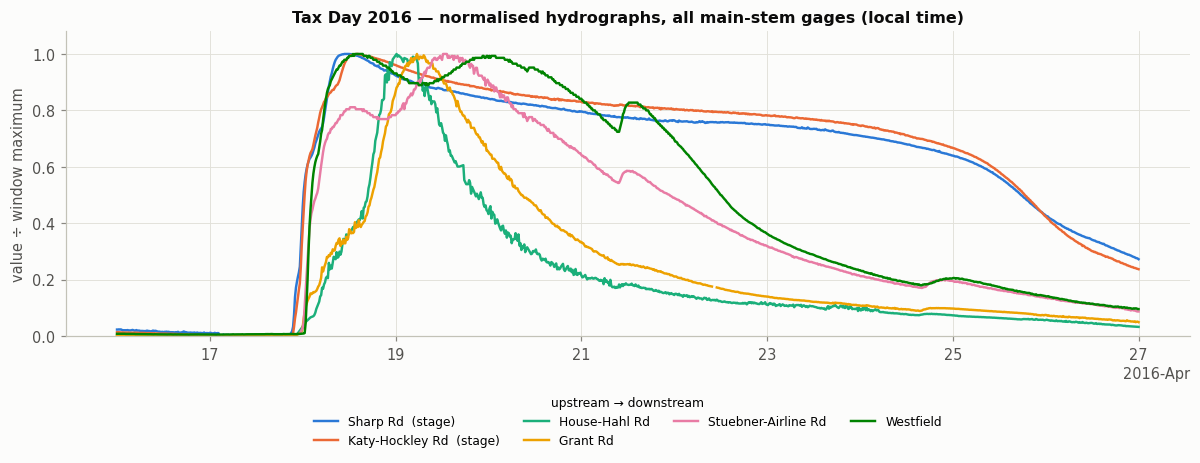

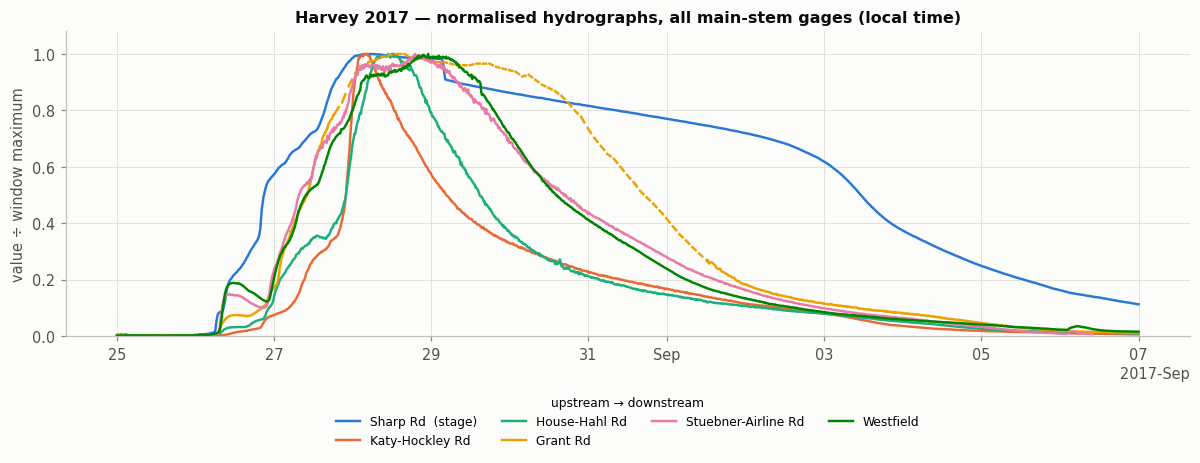

In [11]:
def plot_overlay(ev, Q, H, stem, window, tz):
    fig, ax = plt.subplots(figsize=(11, 4.4))
    for _, r in stem.iterrows():
        s, basis, _ = timing_series(r.site, Q, H, window, tz)
        if s is None: continue
        if basis == "stage": s = s - s.min()                            # stage: rise above the window minimum
        s = s / s.max()
        ax.plot(naive(s.index), s.values, color=r.color, label=r.label + ("  (stage)" if basis == "stage" else ""))
    ax.set_ylim(0, 1.08); ax.set_ylabel("value ÷ window maximum")
    loc = mdates.AutoDateLocator(minticks=6, maxticks=12)
    ax.xaxis.set_major_locator(loc); ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(loc))
    ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.16), ncol=4, fontsize=8, title="upstream → downstream", title_fontsize=8)
    ax.set_title(f"{ev} — normalised hydrographs, all main-stem gages (local time)")
    plt.tight_layout(); plt.show()

for ev in CFG["events"]:
    plot_overlay(ev, DATA[ev]["Q"], DATA[ev]["H"], stem, DATA[ev]["window"], CFG["tz"])

## 7 · Peak table

For each gage and event: peak discharge and its time, peak stage and its time, and the **unit peak**
(cfs per mi² of drainage area) — the cleanest way to compare the intensity of the response between gages
of different size. `crest_h` is how long the record stayed within 2 % of its peak: a crest that lasts hours
(a flat-topped hydrograph, or a gage whose rating is capped) makes the *time* of the peak uncertain by that much.

Multi-day storms produce **several** peaks, and a downstream gage's largest peak is not always the wave from
upstream — it can be local runoff that arrived first. `find_peaks` lists the prominent peaks at each gage
(prominence ≥ 5 % of the range, at least 4 h apart) so you can see the structure before trusting any lag.

In [12]:
def crest_hours(s, t, frac=0.98, step_min=15):
    '''Duration (h) of the contiguous run around time `t` during which `s` stays within the top (1 - frac) of its rise
    (rise = s[t] minus the window minimum, so stage and discharge are treated alike).'''
    lo = s.min(); hi = (s >= lo + frac * (s.loc[t] - lo)).to_numpy(); a = b = s.index.get_loc(t)
    while a > 0 and hi[a - 1]: a -= 1
    while b < len(hi) - 1 and hi[b + 1]: b += 1
    return (b - a) * step_min / 60

def peak_table(ev, Q, H, stem):
    rows = []
    for _, r in stem.iterrows():
        row = dict(event=ev, gage=r.label, da_mi2=r.da_mi2)
        if r.site in Q and Q[r.site].notna().any():
            q = Q[r.site]; t = q.idxmax()
            row.update(Q_peak_cfs=q.max(), t_Q_peak=t, Q_crest_h=crest_hours(q, t), unit_peak_cfs_mi2=q.max() / r.da_mi2)
        if r.site in H and H[r.site].notna().any():
            h = H[r.site]; t = h.idxmax()
            row.update(H_peak_ft=h.max(), t_H_peak=t, H_crest_h=crest_hours(h, t))
        rows.append(row)
    return pd.DataFrame(rows)

def secondary_peaks(ev, Q, H, stem, window, tz, k=3):
    rows = []
    for _, r in stem.iterrows():
        s, basis, _ = timing_series(r.site, Q, H, window, tz)
        if s is None: continue
        v = s.interpolate().bfill().ffill().to_numpy()
        idx, props = find_peaks(v, prominence=0.05 * (v.max() - v.min()), distance=16)   # 16 × 15 min = 4 h
        order = np.argsort(props["prominences"])[::-1][:k]
        for rank, i in enumerate(sorted(idx[order]), 1):
            rows.append(dict(event=ev, gage=r.label, basis=basis, peak_no=rank, time=s.index[i], value=v[i],
                             pct_of_max=100 * v[i] / v.max()))
    return pd.DataFrame(rows)

PEAKS = pd.concat([peak_table(ev, DATA[ev]["Q"], DATA[ev]["H"], stem) for ev in CFG["events"]], ignore_index=True)
display(PEAKS.style.format({"Q_peak_cfs": "{:,.0f}", "unit_peak_cfs_mi2": "{:.1f}", "H_peak_ft": "{:.2f}",
                            "Q_crest_h": "{:.2f}", "H_crest_h": "{:.2f}", "t_Q_peak": "{:%b %d %H:%M}",
                            "t_H_peak": "{:%b %d %H:%M}"}, na_rep="—"))

SECONDARY = pd.concat([secondary_peaks(ev, DATA[ev]["Q"], DATA[ev]["H"], stem, DATA[ev]["window"], CFG["tz"])
                       for ev in CFG["events"]], ignore_index=True)
print("\nProminent peaks per gage (chronological):")
display(SECONDARY.assign(time=SECONDARY.time.map(lambda t: f"{t:%b %d %H:%M}")).round(1))

,event,gage,da_mi2,H_peak_ft,t_H_peak,H_crest_h,Q_peak_cfs,t_Q_peak,Q_crest_h,unit_peak_cfs_mi2
0,Tax Day 2016,Sharp Rd,80.700000,169.83,Apr 18 10:45,7.25,—,—,—,—
1,Tax Day 2016,Katy-Hockley Rd,110.000000,162.34,Apr 18 14:00,8.50,"3,380",Apr 20 00:00,0.50,30.7
2,Tax Day 2016,House-Hahl Rd,131.000000,148.18,Apr 19 00:15,13.75,"20,800",Apr 19 00:15,2.25,158.8
3,Tax Day 2016,Grant Rd,214.000000,127.52,Apr 19 05:30,15.25,"21,000",Apr 19 05:30,3.00,98.1
4,Tax Day 2016,Stuebner-Airline Rd,248.000000,110.46,Apr 19 12:30,14.00,"14,300",Apr 19 12:15,2.50,57.7
5,Tax Day 2016,Westfield,285.000000,90.57,Apr 18 13:45,11.50,"14,500",Apr 18 13:00,6.50,50.9
6,Harvey 2017,Sharp Rd,80.700000,170.05,Aug 28 05:30,27.75,—,—,—,—
7,Harvey 2017,Katy-Hockley Rd,110.000000,162.85,Aug 28 03:30,10.50,"12,800",Aug 28 03:00,3.50,116.4
8,Harvey 2017,House-Hahl Rd,131.000000,149.30,Aug 28 10:45,18.00,"22,600",Aug 28 10:45,7.25,172.5
9,Harvey 2017,Grant Rd,214.000000,129.97,Aug 28 13:00,1.00,"17,500",Aug 28 13:00,1.75,81.8



Prominent peaks per gage (chronological):


,event,gage,basis,peak_no,time,value,pct_of_max
0,Tax Day 2016,Sharp Rd,stage,1,Apr 18 11:15,169.8,100.0
1,Tax Day 2016,Katy-Hockley Rd,stage,1,Apr 18 14:00,162.3,100.0
2,Tax Day 2016,House-Hahl Rd,flow,1,Apr 19 00:15,20800.0,100.0
3,Tax Day 2016,Grant Rd,flow,1,Apr 19 05:30,21000.0,100.0
4,Tax Day 2016,Stuebner-Airline Rd,flow,1,Apr 19 12:45,14300.0,100.0
5,Tax Day 2016,Westfield,flow,1,Apr 18 13:00,14500.0,100.0
6,Tax Day 2016,Westfield,flow,2,Apr 19 23:30,14400.0,99.3
7,Tax Day 2016,Westfield,flow,3,Apr 21 13:15,12000.0,82.8
8,Harvey 2017,Sharp Rd,stage,1,Aug 28 05:30,170.0,100.0
9,Harvey 2017,Katy-Hockley Rd,flow,1,Aug 28 03:00,12800.0,100.0


## 8 · Travel time and celerity

Two simple estimators of the time a flood wave takes to cross a reach, both **tracking one wave downstream**:

1. **Matched peak-to-peak lag.** Take the upstream peak, then look for the downstream peak *only in the window
   `(t_up, t_up + max_lag_hours]`*. Once a downstream peak is matched it becomes the upstream peak for the next
   reach, so the same wave is followed gage to gage. A plain "time of maximum minus time of maximum" fails on
   real rivers: the downstream maximum is often a *different* pulse (local runoff that arrived first, or a later
   storm). When that happens the table says so in `flags`, and the reach is left blank rather than reported wrong.
2. **Windowed cross-correlation lag.** Cut a slice of the upstream hydrograph ±`xcorr_window_hours` around its
   peak and find the delay at which it best matches the downstream record (Pearson *r*, delay ≥ 0). It uses the
   *shape* of the pulse, not one sample, so it is less sensitive to a flat crest — but where a tributary or local
   runoff reshapes the downstream hydrograph it is pulled toward *their* timing, usually toward zero lag.

Dividing reach length by the lag gives the **wave celerity** *c* — the speed of the flood wave, which is **not**
the water velocity. Kinematic-wave theory gives *c ≈ (5/3)·V* for a wide channel in-bank; once flow spills onto a
rough floodplain, storage per unit length grows much faster than conveyance and *c* drops sharply. That is
why the biggest floods on a flat, wide-floodplain stream are often the *slowest* — check whether Cypress Creek
behaves that way below.

In [13]:
def matched_peak(s, t_after, max_lag_h):
    '''Largest value of `s` in (t_after, t_after + max_lag_h]. Returns (time, value, status).'''
    w = s[t_after + pd.Timedelta(minutes=1): t_after + pd.Timedelta(hours=max_lag_h)].dropna()
    if len(w) < 4: return None, np.nan, "no downstream data in search window"
    t, v = w.idxmax(), w.max()
    if t == w.index[0] and s.get(t_after, -np.inf) >= v: return t, v, "downstream already receding at upstream peak"
    if t == w.index[-1]: return t, v, f"downstream still rising {max_lag_h} h later"
    return t, v, "ok"

def xcorr_lag(up, dn, t_up, half_window_h, max_lag_h, step_min=15):
    '''Delay (h) maximising Pearson r between up[t_up ± half_window] and dn shifted by that delay (≥ 0). Returns (lag_h, r).'''
    w = pd.Timedelta(hours=half_window_h)
    x = up[t_up - w: t_up + w]
    best = (np.nan, -np.inf)
    for k in range(0, int(max_lag_h * 60 / step_min) + 1):
        y = dn.reindex(x.index + pd.Timedelta(minutes=k * step_min))
        m = x.notna().to_numpy() & y.notna().to_numpy()
        if m.sum() < 8: continue
        r = np.corrcoef(x.to_numpy()[m], y.to_numpy()[m])[0, 1]
        if r > best[1]: best = (k * step_min / 60, r)
    return best

def travel_time_table(ev, Q, H, stem, window, tz, max_lag_hours, xcorr_window_hours, short_reach_mi=3.0):
    '''One row per reach between consecutive gages that have a usable record in this event.'''
    chain = []
    for _, r in stem.iterrows():
        s, basis, _ = timing_series(r.site, Q, H, window, tz)
        if s is not None: chain.append((r, s, basis))
    rows, t_prev = [], None                     # t_prev = peak matched at the previous gage (if that reach was ok)
    for (r_up, s_up, b_up), (r_dn, s_dn, b_dn) in zip(chain[:-1], chain[1:]):
        t_up = t_prev if t_prev is not None else s_up.idxmax()
        t_dn, v_dn, status = matched_peak(s_dn, t_up, max_lag_hours)
        ok = status == "ok"
        flags = [] if ok else [status]
        if ok and abs(s_dn.idxmax() - t_dn) > pd.Timedelta(hours=1):
            flags.append(f"downstream maximum ({s_dn.idxmax():%b %d %H:%M}) is a different pulse")
        for lab, s, t in [("upstream", s_up, t_up), ("downstream", s_dn, t_dn)]:
            if t is not None and crest_hours(s, t) >= 3: flags.append(f"{lab} crest flat for {crest_hours(s, t):.0f} h")
        d_mi = r_dn.dist_from_top_mi - r_up.dist_from_top_mi
        if d_mi < short_reach_mi: flags.append("short reach: lag is only a few time steps")
        lag_pk = (t_dn - t_up) / pd.Timedelta(hours=1) if ok else np.nan
        if ok and d_mi / lag_pk > 10: flags.append("> 10 mi/h — faster than a flood wave travels; the two gages responded to the same rain")
        lag_xc, r_xc = xcorr_lag(s_up, s_dn, t_up, xcorr_window_hours, max_lag_hours)
        d_km = d_mi * KM_PER_MI
        rows.append(dict(event=ev, reach=f"{r_up.label} → {r_dn.label}", basis=f"{b_up}/{b_dn}", dist_mi=d_mi, dist_km=d_km,
                         t_peak_up=t_up, t_peak_dn=t_dn if ok else pd.NaT,
                         lag_peak_h=lag_pk, c_peak_ms=d_km * 1000 / (lag_pk * 3600) if lag_pk > 0 else np.nan,
                         lag_xcorr_h=lag_xc, r_xcorr=r_xc, c_xcorr_ms=d_km * 1000 / (lag_xc * 3600) if lag_xc > 0 else np.nan,
                         flags="; ".join(flags)))
        t_prev = t_dn if ok else None
    df = pd.DataFrame(rows)
    df["c_peak_mph"], df["c_xcorr_mph"] = df.c_peak_ms * 3600 / 1609.344, df.c_xcorr_ms * 3600 / 1609.344
    return df

TT_COLS = ["event", "reach", "basis", "dist_mi", "t_peak_up", "t_peak_dn", "lag_peak_h", "c_peak_ms", "c_peak_mph",
           "lag_xcorr_h", "r_xcorr", "c_xcorr_ms", "flags"]
TT_FMT = {"dist_mi": "{:.1f}", "t_peak_up": "{:%b %d %H:%M}", "t_peak_dn": "{:%b %d %H:%M}", "lag_peak_h": "{:.2f}",
          "c_peak_ms": "{:.2f}", "c_peak_mph": "{:.2f}", "lag_xcorr_h": "{:.2f}", "r_xcorr": "{:.2f}", "c_xcorr_ms": "{:.2f}"}

def summarise_travel(TT):
    for ev, g in TT.groupby("event", sort=False):
        v, xc = g[g.lag_peak_h > 0], g[g.lag_xcorr_h > 0]
        if v.empty:
            print(f"{ev}: no reach with a matched downstream peak"); continue
        mi, h = v.dist_mi.sum(), v.lag_peak_h.sum()
        msg = f"{ev}: matched peaks on {len(v)} of {len(g)} reaches → {mi:.1f} mi in {h:.1f} h = {mi/h:.2f} mi/h ({mi*KM_PER_MI*1000/(h*3600):.2f} m/s)"
        if not xc.empty: msg += f"; cross-correlation on {len(xc)} reaches → {xc.dist_mi.sum()/xc.lag_xcorr_h.sum():.2f} mi/h"
        print(msg)

TT = pd.concat([travel_time_table(ev, DATA[ev]["Q"], DATA[ev]["H"], stem, DATA[ev]["window"], CFG["tz"],
                                  CFG["max_lag_hours"], CFG["xcorr_window_hours"]) for ev in CFG["events"]], ignore_index=True)
display(TT[TT_COLS].style.format(TT_FMT, na_rep="—"))
summarise_travel(TT)

,event,reach,basis,dist_mi,t_peak_up,t_peak_dn,lag_peak_h,c_peak_ms,c_peak_mph,lag_xcorr_h,r_xcorr,c_xcorr_ms,flags
0,Tax Day 2016,Sharp Rd → Katy-Hockley Rd,stage/stage,3.3,Apr 18 10:45,Apr 18 14:00,3.25,0.45,1.01,3.50,0.99,0.42,upstream crest flat for 7 h; downstream crest flat for 8 h
1,Tax Day 2016,Katy-Hockley Rd → House-Hahl Rd,stage/flow,5.9,Apr 18 14:00,Apr 19 00:15,10.25,0.26,0.58,10.25,0.94,0.26,upstream crest flat for 8 h
2,Tax Day 2016,House-Hahl Rd → Grant Rd,flow/flow,10.7,Apr 19 00:15,Apr 19 05:30,5.25,0.91,2.03,3.50,0.98,1.36,downstream crest flat for 3 h
3,Tax Day 2016,Grant Rd → Stuebner-Airline Rd,flow/flow,8.2,Apr 19 05:30,Apr 19 12:15,6.75,0.54,1.22,7.00,0.98,0.52,upstream crest flat for 3 h
4,Tax Day 2016,Stuebner-Airline Rd → Westfield,flow/flow,7.3,Apr 19 12:15,Apr 19 22:30,10.25,0.32,0.72,10.00,0.99,0.33,downstream maximum (Apr 18 13:00) is a different pulse; downstream crest flat for 10 h
5,Harvey 2017,Sharp Rd → Katy-Hockley Rd,stage/flow,3.3,Aug 28 05:30,—,—,—,—,0.25,0.92,5.89,downstream already receding at upstream peak; upstream crest flat for 28 h; downstream crest flat for 5 h
6,Harvey 2017,Katy-Hockley Rd → House-Hahl Rd,flow/flow,5.9,Aug 28 03:00,Aug 28 10:45,7.75,0.34,0.76,3.50,0.94,0.76,upstream crest flat for 4 h; downstream crest flat for 7 h
7,Harvey 2017,House-Hahl Rd → Grant Rd,flow/flow,10.7,Aug 28 10:45,Aug 28 13:00,2.25,2.12,4.74,2.00,0.99,2.39,upstream crest flat for 7 h
8,Harvey 2017,Grant Rd → Stuebner-Airline Rd,flow/flow,8.2,Aug 28 13:00,Aug 28 19:00,6.00,0.61,1.37,6.00,0.67,0.61,downstream crest flat for 4 h
9,Harvey 2017,Stuebner-Airline Rd → Westfield,flow/flow,7.3,Aug 28 19:00,Aug 28 23:00,4.00,0.82,1.83,5.00,0.86,0.66,upstream crest flat for 4 h; downstream crest flat for 11 h


Tax Day 2016: matched peaks on 5 of 5 reaches → 35.4 mi in 35.8 h = 0.99 mi/h (0.44 m/s); cross-correlation on 5 reaches → 1.03 mi/h
Harvey 2017: matched peaks on 4 of 5 reaches → 32.1 mi in 20.0 h = 1.61 mi/h (0.72 m/s); cross-correlation on 5 reaches → 2.12 mi/h


### Travel-time diagram

Channel distance on the *x*-axis, time of the tracked peak (hours after the earliest peak in that event) on the
*y*-axis — the classic way to show a flood wave. The slope of each line is the **inverse celerity**: steeper means
slower. Filled markers joined by solid lines are matched peaks; a dashed segment ending in a hollow marker is the
windowed cross-correlation estimate for that reach, drawn from the same upstream peak. A break in the line is a
reach where no downstream peak could be matched.

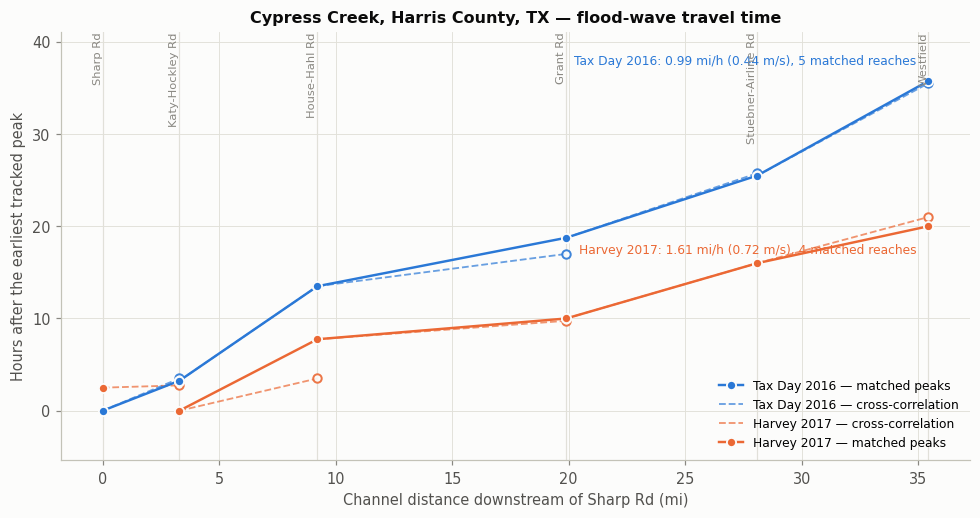

In [14]:
def plot_travel_time_diagram(TT, stem, title):
    fig, ax = plt.subplots(figsize=(9, 4.8))
    xpos = dict(zip(stem.label, stem.dist_from_top_mi))
    for i_ev, (ev, g) in enumerate(TT.groupby("event", sort=False)):
        col = EVENT_COLORS[ev]
        t0 = min(g.t_peak_up.min(), g.t_peak_dn.min())
        hrs = lambda t: (t - t0) / pd.Timedelta(hours=1)
        labels = {"pk": f"{ev} — matched peaks", "xc": f"{ev} — cross-correlation"}   # each legend entry once
        for _, r in g.iterrows():
            up, dn = r.reach.split(" → ")
            x_up, x_dn, y_up = xpos[up], xpos[dn], hrs(r.t_peak_up)
            ax.plot(x_up, y_up, "o", color=col, ms=6, mec=SURFACE, mew=1.2, zorder=3)
            if pd.notna(r.lag_peak_h):
                ax.plot([x_up, x_dn], [y_up, hrs(r.t_peak_dn)], "-o", color=col, ms=6, mec=SURFACE, mew=1.2,
                        label=labels.pop("pk", None), zorder=3)
            if r.lag_xcorr_h > 0:
                ax.plot([x_up, x_dn], [y_up, y_up + r.lag_xcorr_h], "--", color=col, alpha=0.7, lw=1.2,
                        label=labels.pop("xc", None), zorder=2)
                ax.plot(x_dn, y_up + r.lag_xcorr_h, "o", color=col, ms=5.5, mfc=SURFACE, mew=1.3, alpha=0.9, zorder=2)
        v = g[g.lag_peak_h.notna()]
        if len(v) and v.lag_peak_h.sum() > 0:
            c = v.dist_mi.sum() / v.lag_peak_h.sum(); last = v.iloc[-1]
            above = i_ev % 2 == 0                       # alternate the summary label above / below the line
            ax.annotate(f"{ev}: {c:.2f} mi/h ({c*KM_PER_MI*1000/3600:.2f} m/s), {len(v)} matched reaches",
                        (xpos[last.reach.split(' → ')[1]], hrs(last.t_peak_dn)), xytext=(-8, 9 if above else -11),
                        textcoords="offset points", ha="right", va="bottom" if above else "top", fontsize=8, color=col)
    ax.margins(y=0.15)
    for lab, xi in xpos.items():
        ax.axvline(xi, color=GRID, lw=0.8, zorder=0)
        ax.text(xi, ax.get_ylim()[1], lab, rotation=90, va="top", ha="right", fontsize=7.5, color=MUTED)
    ax.set_xlabel(f"Channel distance downstream of {stem.label.iloc[0]} (mi)")
    ax.set_ylabel("Hours after the earliest tracked peak"); ax.set_title(f"{title} — flood-wave travel time")
    ax.legend(fontsize=8, loc="lower right"); plt.tight_layout(); plt.show()

plot_travel_time_diagram(TT, stem, CFG["title"])

## 9 · Interpretation and caveats (Cypress Creek)

What the tables and figures above show — check the numbers against your own run, they are pulled live:

* **Ordering and distances.** NLDI puts six gages on the main stem, Sharp Rd (stage-only) → Katy-Hockley →
  House-Hahl → Grant Rd → Stuebner-Airline → Westfield, ≈ 35 mi of channel. Little Cypress Creek is correctly
  excluded (it joins between House-Hahl and Grant Rd, so that reach has a large lateral inflow).
* **Tax Day 2016** — one intense night of rain (17–18 April). The matched peaks step downstream cleanly:
  Sharp Rd 10:45 → Katy-Hockley 14:00 → House-Hahl 00:15 → Grant Rd 05:30 → Stuebner 12:15 → Westfield 22:30,
  **≈ 36 h for 35 mi, c ≈ 1 mi/h (0.44 m/s)**, and the windowed cross-correlation agrees on every reach. That is slow:
  Cypress Creek is a low-gradient coastal-prairie stream (≈ 3–5 ft/mi) with a wide floodplain, and Tax Day put most of
  the water *on* that floodplain. Two things a naive analysis would have got wrong: Katy-Hockley's discharge record
  has a 47-hour gap across the crest (the §5 check switched it to stage), and Westfield's *largest* peak (Apr 18
  13:00) is local urban runoff that arrived a day before the upstream wave — the matched search found the second,
  broader peak that is the wave. Look at the Westfield panel in the stacked plot: two crests of almost equal height.
* **Harvey 2017** — four days of rain over the whole basin. The crests still progress downstream (Katy-Hockley 03:00
  → Westfield 23:00 on 28 August, **≈ 1.6 mi/h**), but read the `flags`: crests are flat for 4–11 h, so each lag is
  uncertain by hours, and the House-Hahl → Grant Rd reach comes out implausibly fast (2 h for 10.7 mi). With rain
  still falling everywhere, the time of the crest at each gage is set as much by *when the rain stopped there* as by
  routing from upstream — the "celerity" is partly a rainfall-timing artefact. Sharp Rd is refused outright: its
  stage flat-tops at ≈ 170 ft, the level at which Cypress Creek spills over its divide into the Addicks watershed,
  so the gage records a pond, not a wave.
* **Bigger was not slower here.** Textbook theory says overbank storage should make the larger flood travel *slower*;
  Harvey came out faster than Tax Day. That is not a refutation — it is the previous point: Harvey's crest timing is
  not a clean routing signal. The honest conclusion from two storms is *c ≈ 0.4–0.7 m/s, with the single-pulse storm
  the more trustworthy of the two.* Testing the storage effect properly needs several single-pulse events of
  different size — exercise 7.

**Caveats a hydrologist would want you to state:**

1. Peak timing has a ±15 min quantisation from the data step, plus the crest-duration uncertainty in the `flags`.
   Rating-curve hysteresis can shift the discharge peak relative to the stage peak by tens of minutes.
2. Provisional data (see the QA table in §5) can be revised. Approved data are what you cite.
3. NLDI distances are from the medium-resolution NHDPlus network; expect ±10 % vs. engineering river miles.
4. The two-gage lag is a *bulk* property of the reach: it folds together channel travel, floodplain storage,
   tributary inflow and any structure (bridges, detention basins, dams) in between. It is not a channel velocity.
5. Both estimators assume the downstream hydrograph contains a delayed copy of the upstream one. Where local runoff
   or a tributary contributes a comparable volume, the cross-correlation is pulled toward *their* timing (often
   toward zero lag) and the matched peak may land on the wrong pulse. The `flags` column and the prominent-peaks
   table are there so you notice.

## 10 · Now you: the Guadalupe River

Every function above takes the configuration as input, so re-applying the analysis is one call. The
`guadalupe_upper` entry in §1 covers the main stem from **Hunt** down to **Spring Branch** — deliberately stopping
above **Canyon Lake**. A reservoir stores the wave and releases it on an operating schedule, so a gage-to-gage
lag across a dam measures the operator, not the river.

Two events are pre-loaded: **October 2018** (the storm that also produced the Llano River flood) and the
**July 4 2025** flood (177,000 ft³/s at Comfort — the largest peak in the gage's record). Both are Hill Country flash
floods whose rain fell on the headwaters, so the wave really does start at Hunt and march down the river. Before you
run the cell, write down a guess: will the Guadalupe's celerity be larger or smaller than Cypress Creek's, and by how
much?

The call below reproduces §2–§8 for the new configuration in one function (`run_pipeline`, defined here from the
same building blocks). Everything that follows the call is produced by exactly the code you have already read.

,site,label,da_mi2,dist_from_top_mi
0,USGS-08165500,Hunt,288.0,0.00
1,USGS-08166140,abv Bear Ck at Kerrville,494.0,8.35
2,USGS-08166200,Kerrville,510.0,10.68
3,USGS-08166250,Center Point,553.0,17.02
4,USGS-08167000,at Comfort,839.0,34.67
5,USGS-08167200,FM 474,1103.0,65.25
6,USGS-08167500,Spring Branch,1315.0,97.75


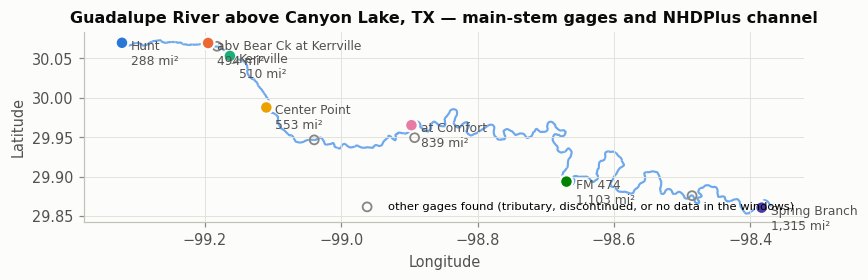

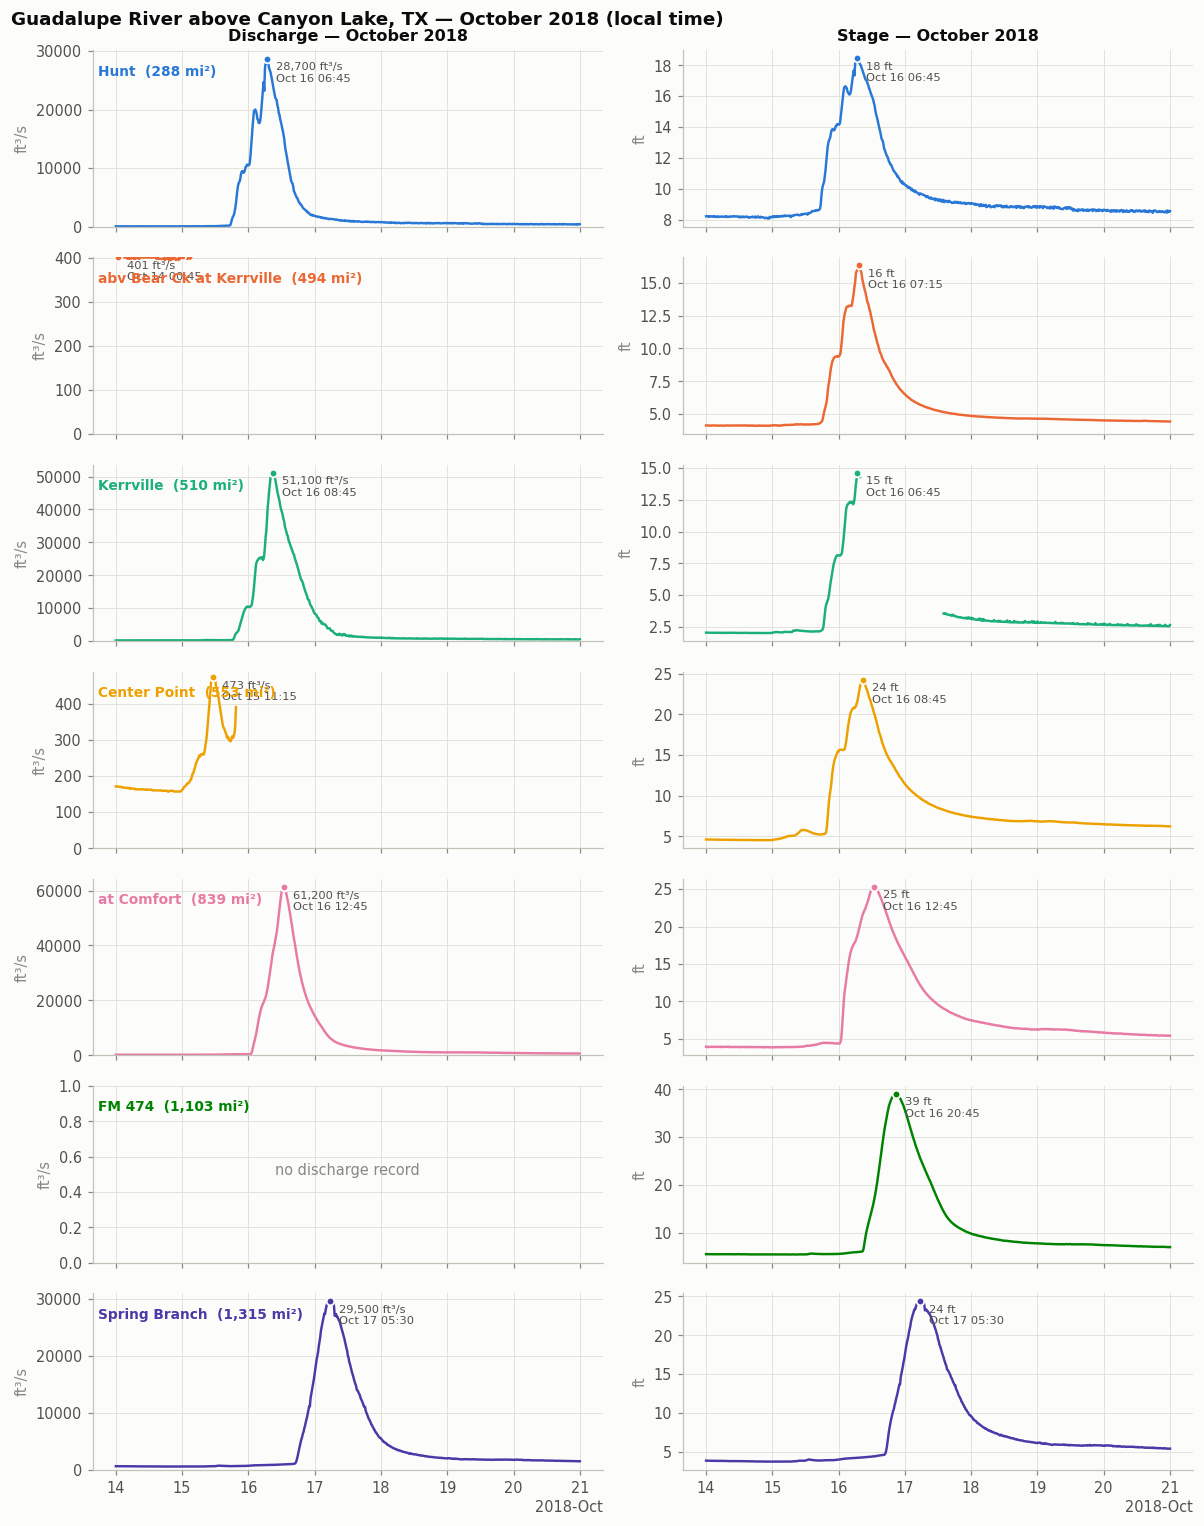

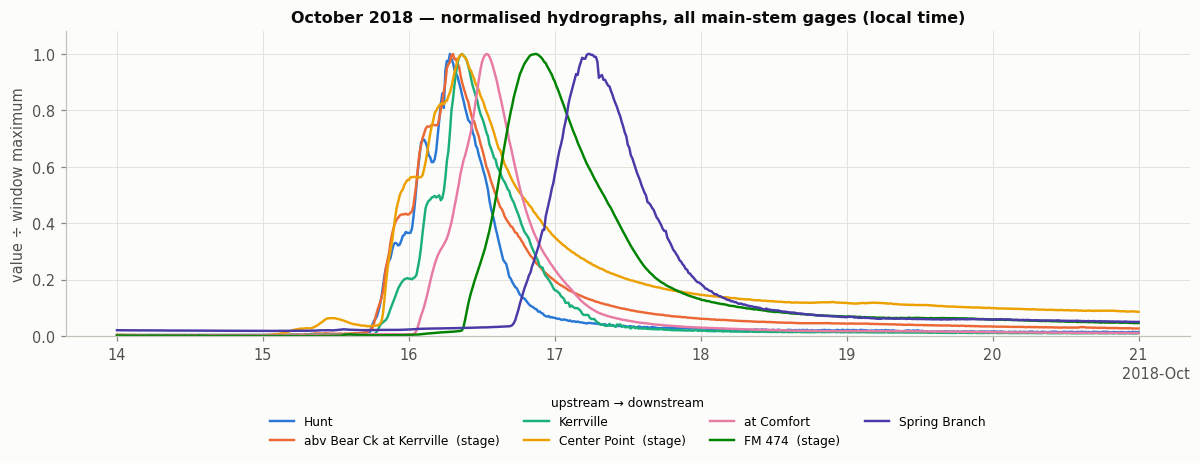

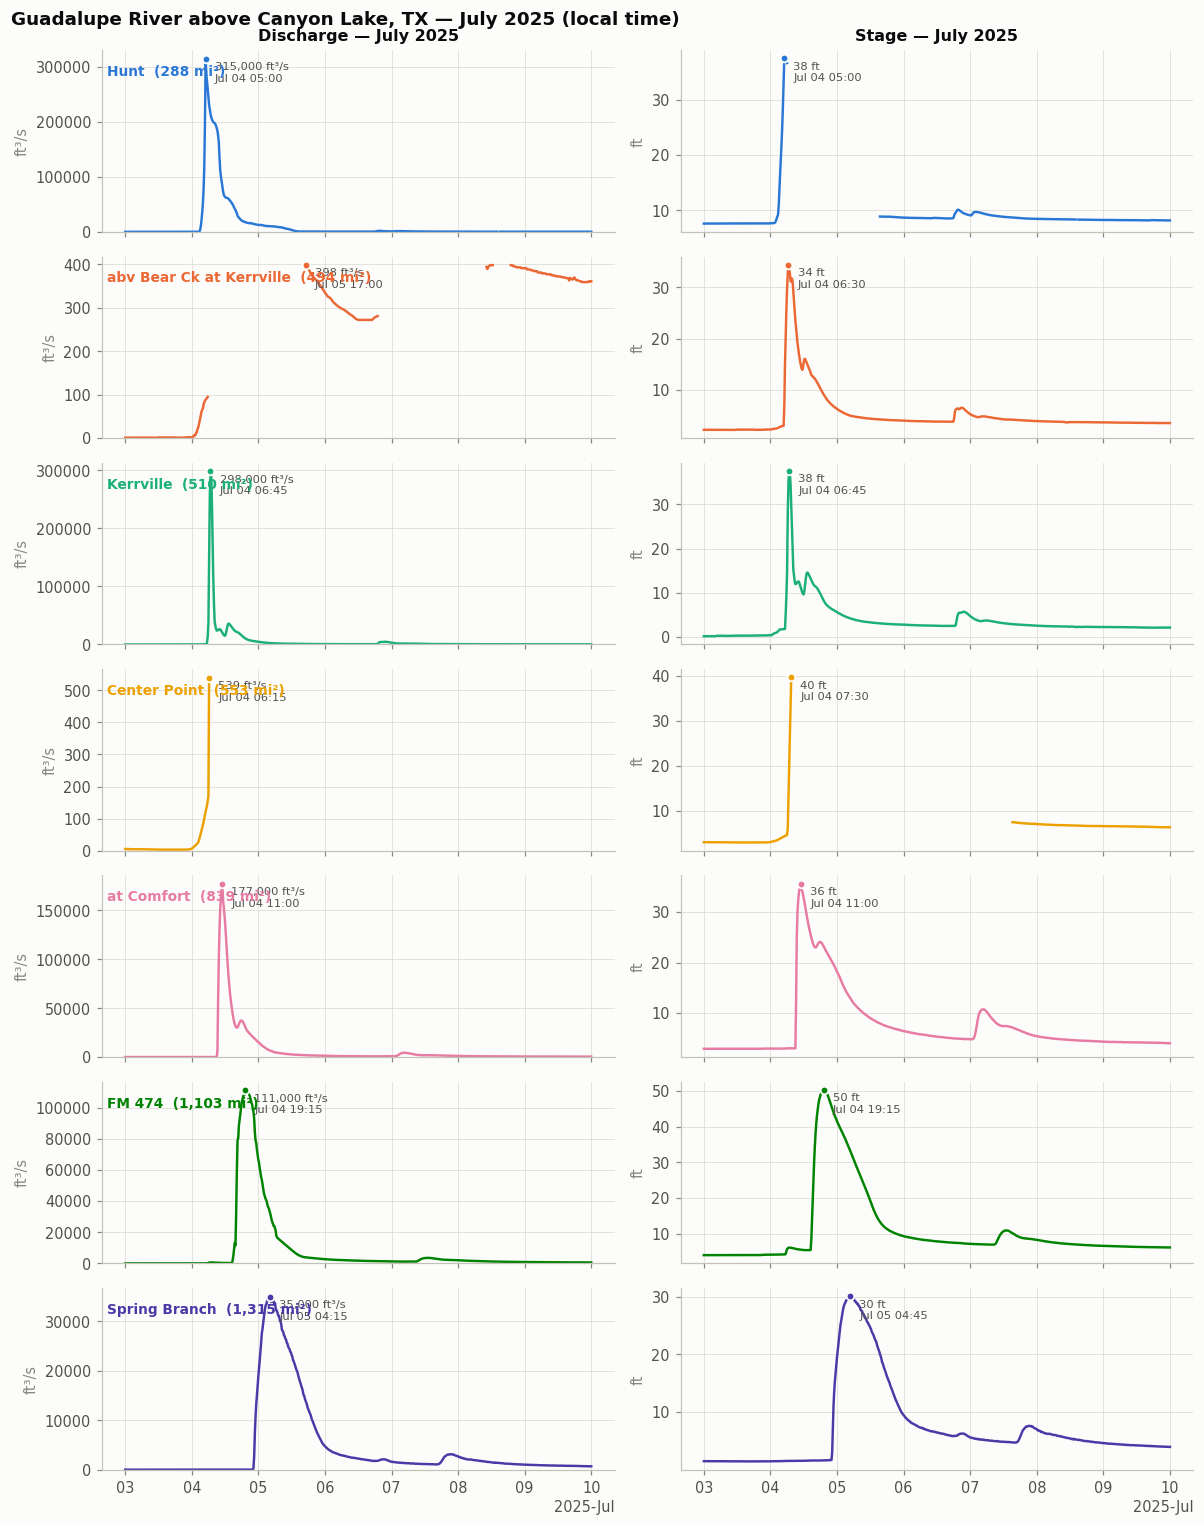

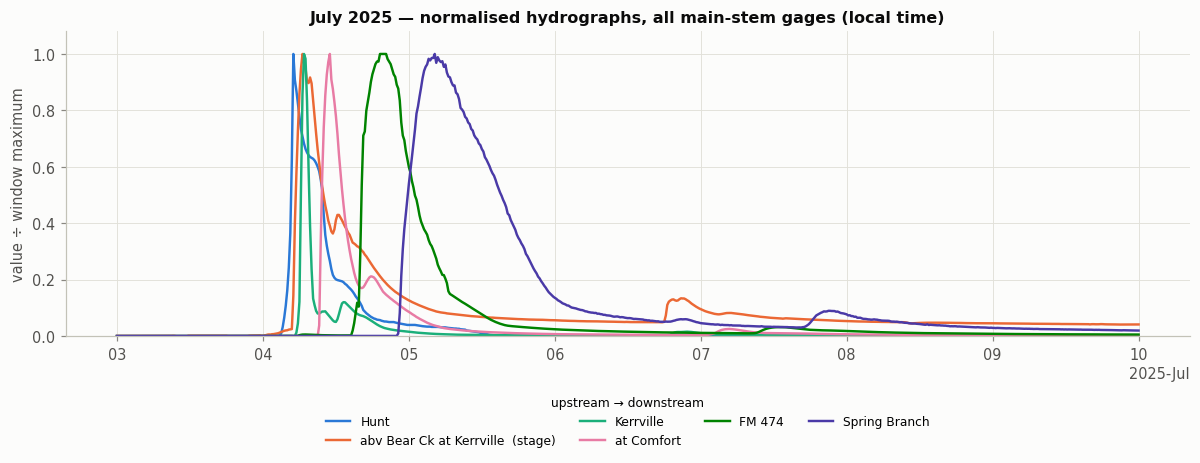

,event,gage,timing_basis,note
1,October 2018,abv Bear Ck at Kerrville,stage,"flow rejected: 15% coverage, longest gap 1.2 h"
3,October 2018,Center Point,stage,"flow rejected: 26% coverage, longest gap 0.0 h"
5,October 2018,FM 474,stage,no flow
8,July 2025,abv Bear Ck at Kerrville,stage,"flow rejected: 52% coverage, longest gap 39.0 h"
10,July 2025,Center Point,— unusable,"flow rejected: 18% coverage, longest gap 0.0 h..."


,event,reach,basis,dist_mi,t_peak_up,t_peak_dn,lag_peak_h,c_peak_ms,c_peak_mph,lag_xcorr_h,r_xcorr,c_xcorr_ms,flags
0,October 2018,Hunt → abv Bear Ck at Kerrville,flow/stage,8.3,Oct 16 06:45,Oct 16 07:15,0.50,7.46,16.70,0.25,0.98,14.93,> 10 mi/h — faster than a flood wave travels; the two gages responded to the same rain
1,October 2018,abv Bear Ck at Kerrville → Kerrville,stage/flow,2.3,Oct 16 07:15,Oct 16 08:45,1.50,0.69,1.55,2.00,0.88,0.52,short reach: lag is only a few time steps
2,October 2018,Kerrville → Center Point,flow/stage,6.3,Oct 16 08:45,—,—,—,—,0.00,0.86,—,downstream already receding at upstream peak
3,October 2018,Center Point → at Comfort,stage/flow,17.6,Oct 16 08:45,Oct 16 12:45,4.00,1.97,4.41,4.25,0.98,1.86,
4,October 2018,at Comfort → FM 474,flow/stage,30.6,Oct 16 12:45,Oct 16 20:45,8.00,1.71,3.82,8.25,0.96,1.66,
5,October 2018,FM 474 → Spring Branch,stage/flow,32.5,Oct 16 20:45,Oct 17 05:30,8.75,1.66,3.71,9.00,0.99,1.61,
6,July 2025,Hunt → abv Bear Ck at Kerrville,flow/stage,8.3,Jul 04 05:00,Jul 04 06:30,1.50,2.49,5.57,1.00,0.97,3.73,
7,July 2025,abv Bear Ck at Kerrville → Kerrville,stage/flow,2.3,Jul 04 06:30,Jul 04 06:45,0.25,4.16,9.32,0.25,0.72,4.16,short reach: lag is only a few time steps
8,July 2025,Kerrville → at Comfort,flow/flow,24.0,Jul 04 06:45,Jul 04 11:00,4.25,2.52,5.64,4.00,0.81,2.68,
9,July 2025,at Comfort → FM 474,flow/flow,30.6,Jul 04 11:00,Jul 04 19:15,8.25,1.66,3.71,7.50,0.78,1.82,


October 2018: matched peaks on 5 of 6 reaches → 91.4 mi in 22.8 h = 4.02 mi/h (1.80 m/s); cross-correlation on 5 reaches → 3.85 mi/h
July 2025: matched peaks on 5 of 5 reaches → 97.8 mi in 23.2 h = 4.20 mi/h (1.88 m/s); cross-correlation on 5 reaches → 4.71 mi/h


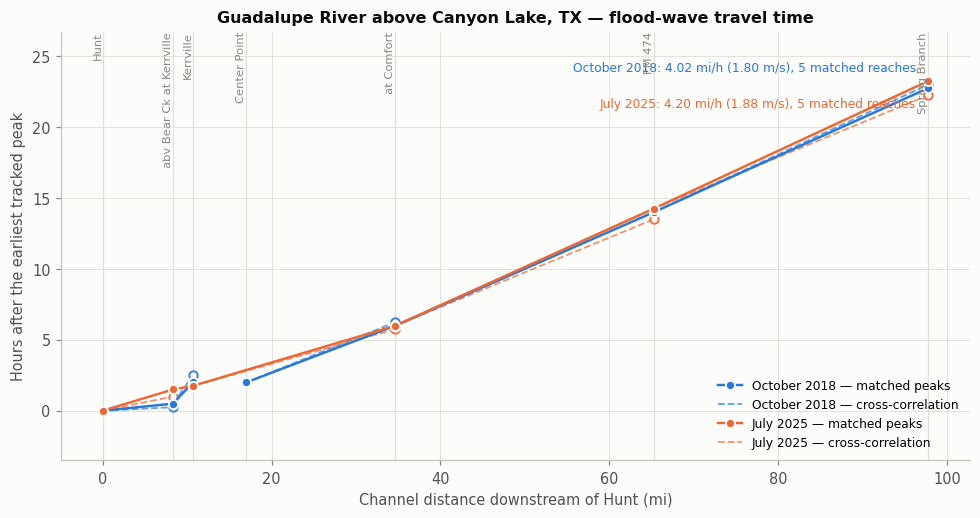

In [15]:
def run_pipeline(cfg, show_stacked=False):
    '''The whole notebook for one configuration. Returns dict of the intermediate tables.'''
    global CFG, EVENT_COLORS                          # the plotting helpers read these
    CFG = cfg; EVENT_COLORS = dict(zip(cfg["events"], PALETTE))
    g = add_labels(find_gages(cfg["huc_prefix"], cfg["name_like"], cfg["exclude"]))
    g = g.merge(iv_availability(g["site"]), on="site", how="left")
    for col in ["flow_begin", "flow_end", "stage_begin", "stage_end"]:
        if col not in g: g[col] = pd.NaT
    for ev, (start, stop) in cfg["events"].items():
        g[f"flow:{ev}"]  = [covers(b, e, start, stop) for b, e in zip(g.flow_begin,  g.flow_end)]
        g[f"stage:{ev}"] = [covers(b, e, start, stop) for b, e in zip(g.stage_begin, g.stage_end)]
    g["usable"] = g[[c for c in g if ":" in c]].any(axis=1)
    u = g[g.usable].sort_values("da_mi2")
    members = main_stem_members(u.iloc[-1]["site"], u["site"].tolist())
    if cfg["override_order"]: members = [s for s in cfg["override_order"] if s in set(u.site)]
    st = u[u.site.isin(members)].set_index("site").loc[members].reset_index(); st["color"] = PALETTE[:len(st)]
    px = {s: gage_position(s) for s in st.site}; dmx = {s: downstream_flowlines(s) for s in st.site}
    rc = []
    for a, b in zip(st.site[:-1], st.site[1:]):
        d, between = reach_distance_km(a, b, px, dmx)
        if cfg["override_distance_km"] and (a, b) in cfg["override_distance_km"]: d = cfg["override_distance_km"][(a, b)]
        rc.append(dict(up=a, dn=b, up_label=st.set_index("site").label[a], dn_label=st.set_index("site").label[b],
                       dist_km=d, dist_mi=d / KM_PER_MI, n_flowlines=len(between)))
    rc = pd.DataFrame(rc); st["dist_from_top_mi"] = np.r_[0.0, rc.dist_mi.cumsum().to_numpy()]
    display(st[["site", "label", "da_mi2", "dist_from_top_mi"]].round(2))
    plot_map(st, g, dmx, px, cfg["title"])
    data, tts, bases = {}, [], []
    for ev, (start, stop) in cfg["events"].items():
        iv = fetch_iv(st.site, start, stop, cfg["tz"])
        Q, H = to_wide(iv, "00060", cfg["tz"]), to_wide(iv, "00065", cfg["tz"])
        data[ev] = dict(raw=iv, Q=Q, H=H, window=(start, stop))
        bases.append(timing_basis_table(ev, Q, H, st, (start, stop), cfg["tz"]))
        if show_stacked: plot_stacked(ev, Q, H, st)
        plot_overlay(ev, Q, H, st, (start, stop), cfg["tz"])
        tts.append(travel_time_table(ev, Q, H, st, (start, stop), cfg["tz"], cfg["max_lag_hours"], cfg["xcorr_window_hours"]))
    basis = pd.concat(bases, ignore_index=True); display(basis[basis.note != ""])
    tt = pd.concat(tts, ignore_index=True)
    display(tt[TT_COLS].style.format(TT_FMT, na_rep="—")); summarise_travel(tt)
    plot_travel_time_diagram(tt, st, cfg["title"])
    peaks = pd.concat([peak_table(ev, data[ev]["Q"], data[ev]["H"], st) for ev in cfg["events"]], ignore_index=True)
    return dict(gages=g, stem=st, reaches=rc, data=data, basis=basis, travel=tt, peaks=peaks)

GUAD = run_pipeline(CONFIGS["guadalupe_upper"], show_stacked=True)

### Exercises

1. **Check the ordering.** Open the map and the `stem` table in `GUAD`. Is every gage really on the main stem, in the
   right order? (Drainage area is a heuristic; the NLDI navigation is the authority. What happens if you drop `"N Fk"`
   from `exclude`?)
2. **Compare celerities.** Hill Country vs. coastal prairie — by what factor do they differ, and which of the physical
   controls in §8 explains most of it: slope, floodplain width, or channel roughness?
3. **Cross the dam.** Add the gages below Canyon Lake (Sattler `USGS-08167800`, above Comal `USGS-08168500`,
   New Braunfels `USGS-08169500`) by changing `huc_prefix` to `"121002"` and extending the exclusion list. Plot the
   July 2025 stacked hydrographs. What does the reservoir do to the wave's shape and timing?
4. **Rising-limb timing.** Peak timing is one choice. Write a function that finds the time each gage first exceeds
   50 % of its peak and recompute lags from that. Is the rising limb faster or slower than the peak? (It should be
   faster — the wave front travels ahead of the crest.)
5. **Centroid lag.** Replace the peak with the time-centroid of the hydrograph above a baseflow you estimate from the
   window minimum. This is the most robust estimator for multi-peak storms; compare it with the cross-correlation.
6. **Unit peaks along the river.** Plot `unit_peak_cfs_mi2` against `da_mi2` for each event. Why does the unit
   peak fall downstream, and does it fall faster on the Guadalupe or on Cypress Creek?
7. **Does bigger travel slower?** Two storms cannot answer that. Use `waterdata.get_peaks` on Westfield
   (`USGS-08069000`) to list the annual peaks, pick five or six *single-pulse* storms of different size since 2008,
   add them to `events`, and plot the Sharp Rd → Westfield celerity against the Westfield peak discharge.
8. **Your river.** Add a third entry to `CONFIGS`. The Blanco (HUC-8 `12100203`, name `%Blanco Rv%`) and the Llano
   (HUC-8 `12090204`, `%Llano Rv%`) both have well-gauged flash floods (May 2015 and October 2018 respectively).

### Where to go next

* USGS Water Data APIs documentation: <https://api.waterdata.usgs.gov/docs/>
* `dataretrieval` documentation: <https://doi-usgs.github.io/dataretrieval-python/>
* NLDI: <https://waterdata.usgs.gov/blog/nldi-intro/>
* On flood-wave celerity and attenuation: Henderson, *Open Channel Flow* (1966), ch. 9; or any hydrology text's
  chapter on flood routing (kinematic vs. diffusive waves).